# 12 — Training encoders with a fair masking comparison

Which missing observations help a JEPA preserve useful movement? Notebook
11 defines where the observations are hidden. This notebook trains paired
encoders while holding their other training choices constant. Notebook 13
then measures how well the resulting features support movement prediction.

The early examples use generated poses and three optimizer updates per
condition. The retained execution of Section 6 also contains a completed
real-data comparison: 50 encoders trained across five source-video groups
and five seeds, with 1,200 updates per encoder. Its saved predictions cover
625 clips from 93 videos. Section 7 explains what that comparison found,
while the small examples remain software demonstrations.

The real-data section displays its training recipe and workload before
training starts. See [the experiment specification](docs/COMPARATIVE_MASKING_PLAN.md)
for the questions assigned to each comparison.

## 1. Keep the comparison focused

First compare where scattered targets are eligible: twelve gait landmarks,
all 33 landmarks, three preselected random sets, or a soft gait preference.
Every condition receives the same number of hidden observations. Random
sets are selected before examining outcomes and should be reported together.

Next compare a structured mask with a scattered reference at its realized
count. For example, hiding two entire joint trajectories and hiding the
same number of scattered tokens create different prediction tasks. The
regularizer continues to pool the twelve gait landmarks, and all 33
landmarks remain input to the encoder. Those anatomical choices are common
to the compared methods.

In [1]:
from pathlib import Path
import os
import sys
from dataclasses import asdict, replace
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("svg", "png")
candidates = [Path.cwd(), *Path.cwd().parents]
SUITE_ROOT = next(p if (p / "laterality").is_dir() else p / "neurips-laterality"
    for p in candidates if (p / "laterality").is_dir() or (p / "neurips-laterality/laterality").is_dir())
sys.path.insert(0, str(SUITE_ROOT))
from laterality_extensions.masked_learning import LearningSettings, load_learning_dataset
from laterality_extensions.comparative_masks import MaskPolicy, MaskBudget
from laterality_extensions.comparative_training import (
    train_comparison, default_conditions, anatomical_conditions, masks_for_batch,
    saved_reference_recipe, plan_real_comparison, run_real_comparison,
)
from notebook_progress import (
    NotebookTaskProgress, run_real_masking_comparison_with_progress,
)
data = load_learning_dataset()
settings = LearningSettings(steps=3, batch_size=5)
print("Synthetic demonstration: generated movement, three updates per encoder.")
display(pd.DataFrame([{"training sources": len(data.train_sources),
    "test sources": len(data.test_sources), "generated clips": len(data.xyz)}]))

Synthetic demonstration: generated movement, three updates per encoder.


,training sources,test sources,generated clips
0,20,5,70


## 2. Inspect actual hidden counts before training

One token contains four consecutive samples of one landmark. A requested
fraction of the gait pool differs from that fraction of the whole input.
The helper chooses a count feasible for every example and policy in the
batch, leaving visible context. A smaller common budget also applies to
its reference conditions.

The automatic scattered budget retains Notebook 08's fraction of the
available gait pool, even when both policies can hide any landmark.
This preserves the reference exposure while keeping an anatomical
influence on the budget. An explicit shared hidden count can test
other exposures as a separately declared comparison.

The following example checks several fixed random pools as well as the
two original target choices. It only constructs masks. The deliberately
small training example below uses the two original choices.

In [2]:
conditions = anatomical_conditions()
masks, coverage = masks_for_batch(data, data.train_rows[:5], settings, conditions)
display(pd.DataFrame([{"condition": name,
    "smallest_hidden_count": int(mask.sum((1, 2)).min()),
    "largest_hidden_count": int(mask.sum((1, 2)).max())}
    for name, mask in masks.items()]))
assert len({tuple(mask.sum((1, 2))) for mask in masks.values()}) == 1

,condition,smallest_hidden_count,largest_hidden_count
0,gait_targets,24,24
1,all_landmark_targets,24,24
2,random_set_31,24,24
3,random_set_47,24,24
4,random_set_59,24,24
5,soft_gait_preference,24,24


The six rows above all hide 24 targets in each of the five generated
examples. The random subsets and soft gait preference have been checked
for feasible mask construction here; this table contains no trained result
for those policies. The training comparison below uses gait-only and
all-landmark scattered targets.

## 3. Pair the training choices that could otherwise explain a difference

Each condition starts with identical encoder, teacher, predictor, and
regularizer weights. The source-video schedule and geometric views are
shared. Policy-specific random streams generate masks independently, so
a sampler's additional random draws cannot change its training clips.

The student predicts features supplied by an unmasked teacher. Its loss
averages hidden targets within each clip and then averages clips. This
preserves the comparison when missing measurements give structured masks
different counts in different clips. The target center uses the same clip
weighting. Invalid measurements never become targets.

,same_initialization,same_projector_initialization,same_source_draws,same_geometric_views,same_hidden_counts
0,True,True,True,True,True


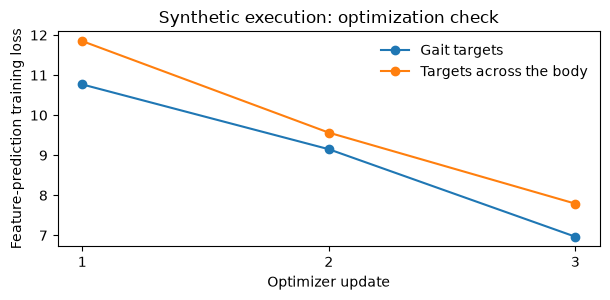

In [3]:
comparison = train_comparison(data, settings, default_conditions(), checkpoint_steps=(1, 3))
display(pd.DataFrame([comparison["pairing"]]))
assert all(comparison["pairing"].values())
history = pd.concat([run["history"].assign(condition=name)
    for name, run in comparison["runs"].items()], ignore_index=True)
fig, ax = plt.subplots(figsize=(6.2, 3.1))
labels = {"gait_targets": "Gait targets", "all_landmark_targets": "Targets across the body"}
for name, group in history.groupby("condition", sort=False):
    ax.plot(group.step, group.masked_prediction_loss, marker="o", label=labels[name])
ax.set(xlabel="Optimizer update", ylabel="Feature-prediction training loss",
       title="Synthetic execution: optimization check")
ax.set_xticks([1, 2, 3]); ax.legend(frameon=False); fig.tight_layout()
display(fig); plt.close(fig)

All five pairing checks pass in this generated example, including matched
initial weights, source draws, geometric views, and hidden counts. These
checks show that the intended controls hold for the displayed execution.

Three updates establish that the learning path executes. Even a falling
loss would leave the movement question open: the teacher also changes
during training, and less variable teacher features can be easier to
predict. Notebook 13 evaluates a shared movement outcome and compares
both trained encoders with their initial states.

## 4. Match each intact structure with its own reference

A complete trajectory stays hidden throughout the window. Missing
measurements may lower its count without shortening its temporal span.
The scattered reference below matches that actual count separately in
every clip. Both models receive the same clip weight in the loss. The two
arms are interleaved, so the displayed wall time describes their paired
job and should not be added across condition rows.

A temporal gap cannot always share that count. With 16 time blocks and
33 visible landmarks, trajectories add 16 tokens at a time and complete
time blocks add 33. Their only common positive count hides the whole
input. These families therefore need separate matched references.

In [4]:
shape_conditions = {"whole_trajectories": MaskPolicy("whole_trajectory"),
                    "scattered_reference": MaskPolicy("uniform")}
shape_budgets = {"whole_trajectories": MaskBudget(trajectories=2)}
shape_example = train_comparison(data, replace(settings, steps=2), shape_conditions,
    budgets=shape_budgets, matched_to="whole_trajectories")
display(pd.DataFrame([shape_example["pairing"]]))
display(pd.DataFrame([{"condition": name, "updates": len(run["history"]),
    "paired_job_wall_seconds": run["elapsed_training_seconds"]}
    for name, run in shape_example["runs"].items()]).round(2))

,same_initialization,same_projector_initialization,same_source_draws,same_geometric_views,same_hidden_counts
0,True,True,True,True,True


,condition,updates,paired_job_wall_seconds
0,whole_trajectories,2,0.02
1,scattered_reference,2,0.02


## 5. Retain compatible results without overwriting them

A saved comparison includes configuration, data and source partitions,
mask coverage, source schedules, losses, and declared encoder checkpoints.
Reuse verifies both compatibility and file contents. During a long
real-data job, both arms are checkpointed at the same update boundary.
If the kernel stops, the next identical request resumes from the last
verified boundary instead of discarding all work for that job.

This short temporary-directory example demonstrates reuse. Real runs use
a dedicated output directory, and their readout predictions are retained
separately from training checkpoints.

In [5]:
with tempfile.TemporaryDirectory(prefix="masking_teaching_") as temporary:
    first = train_comparison(data, replace(settings, steps=1), output_dir=temporary)
    repeated = train_comparison(data, replace(settings, steps=1), output_dir=temporary)
    print("Completed compatible comparison reused:", repeated["reused"])

Completed compatible comparison reused: True


## 6. Inspect and optionally run the real-data grid

The settings below are read from all 25 retained Notebook 08 comparisons.
Their agreement is checked before the reference is returned. The recipe
has a constant learning rate and teacher momentum; it is not the small
synthetic setup used above. The original [S-JEPA paper](https://www.ecva.net/papers/eccv_2024/papers_ECCV/papers/04755.pdf)
provides the feature-prediction motivation, while our comparative training
retains the current project's architecture and regularizer.

The full two-condition plan contains 50 encoders and 60,000 optimizer
updates across five outer video groups and five seeds. Input validation
reads the local prepared data and checks mask feasibility without training.

The runner uses PyTorch's native CUDA backend on an NVIDIA GPU or its MPS
backend on an Apple GPU. It keeps each fold's poses, validity masks, and
presampled target masks on that device; generates one pair of augmented
views for both masking arms; and reduces feature tensors before copying
summaries back to the CPU. On a single GPU, fold/seed jobs run one at a
time so that concurrent models do not compete for accelerator memory.
Tensor operations within each job are already batched and parallel.

MLX is not selected automatically. It is not a drop-in execution backend
for this PyTorch model, optimizer, and checkpoint format; a native MLX
port would be a separate numerical implementation that needs its own
equivalence study. MPS therefore provides the valid Metal-accelerated path
for this comparison today.

Set `LATERALITY_RESEARCH_RUN_REAL=1` to enable training and optionally set
`LATERALITY_DEVICE` to `mps`, `cuda`, or `cpu` (otherwise `auto` is used). The log
first explains the total work, hardware, memory strategy, and recovery
policy. A single updating `notebook_progress.py` display then shows the
active fold, seed, masking arm, optimizer position, latest sampled loss,
elapsed time, and adaptive ETA. The ordinary text log still reports only
one start and one plain-language result per fold/seed job instead of
printing the 50-row workload or every optimizer update. Complete jobs are
reused. Interrupted jobs save both arms together
every 300 updates per arm. Because each recovery file contains both models
and both optimizer states, this interval cuts checkpoint traffic by two
thirds relative to saving every 100 updates while limiting repeated work
after an interruption to at most 300 updates per arm.

The retained log below now reports a completed real-data run. Its 25
completed training manifests and 25 saved evaluations have been checked
against the declared folds and seeds. One job resumed from its saved
update boundary; the complete training histories still contain all 1,200
updates for both encoders in every job. The interpretation below uses
the completed saved predictions, rather than treating the workload preview
or a progress message alone as evidence of predictive performance.

In [6]:
recipe = saved_reference_recipe()
display(pd.DataFrame([
    {
        "part of the run": "Exposure",
        "chosen setting": f"{recipe['steps']:,} updates × batch {recipe['batch_size']} per encoder",
        "reason": "Matches the retained Notebook 08 training budget",
    },
    {
        "part of the run": "Encoder",
        "chosen setting": (
            f"{recipe['embed_dim']}-D; encoder depth {recipe['encoder_depth']}; "
            f"predictor depth {recipe['predictor_depth']}; {recipe['heads']} heads"
        ),
        "reason": "Keeps architecture fixed so only the masking policy changes",
    },
    {
        "part of the run": "Optimization",
        "chosen setting": (
            f"{recipe['optimizer']}; learning rate {recipe['learning_rate']}; "
            f"weight decay {recipe['weight_decay']}; teacher momentum {recipe['ema_momentum']}"
        ),
        "reason": "Uses the same optimizer recipe for both independent arms",
    },
]))
VALIDATE_REAL_INPUTS = os.getenv("LATERALITY_RESEARCH_VALIDATE_REAL", "1") == "1"
RUN_REAL_TRAINING = os.getenv("LATERALITY_RESEARCH_RUN_REAL", "0") == "1"
REAL_DEVICE = os.getenv("LATERALITY_DEVICE", "auto")
real_plan = plan_real_comparison(conditions=default_conditions(),
    validate_inputs=VALIDATE_REAL_INPUTS, device=REAL_DEVICE)
display(pd.DataFrame([{
    "scope": real_plan["scope"],
    "fold/seed comparisons": len(real_plan["folds"]) * len(real_plan["seeds"]),
    "encoder arms": real_plan["training_runs"],
    "updates": real_plan["optimizer_updates"],
    "clip presentations": real_plan["sample_presentations"],
    "requested device": REAL_DEVICE,
    "real training enabled": RUN_REAL_TRAINING,
}]))
if len(real_plan["input_checks"]):
    display(real_plan["input_checks"])
if RUN_REAL_TRAINING:
    real_training_progress = NotebookTaskProgress(
        "Real controlled-masking experiment",
        "stage",
        refresh_seconds=0.5,
    )
    real_result = run_real_masking_comparison_with_progress(
        real_plan,
        progress=real_training_progress,
        progress_interval=100,
        resume_interval=300,
    )
else:
    real_result = run_real_comparison(
        real_plan,
        enabled=False,
        resume_interval=300,
    )

,part of the run,chosen setting,reason
0,Exposure,"1,200 updates × batch 20 per encoder",Matches the retained Notebook 08 training budget
1,Encoder,96-D; encoder depth 4; predictor depth 2; 4 heads,Keeps architecture fixed so only the masking p...
2,Optimization,AdamW; learning rate 0.001; weight decay 0.05;...,Uses the same optimizer recipe for both indepe...


,scope,fold/seed comparisons,encoder arms,updates,clip presentations,requested device,real training enabled
0,full declared comparison,25,50,60000,1200000,auto,True


,fold,train_clips,test_clips,train_sources,test_sources
0,0,436,189,74,19
1,1,443,182,74,19
2,2,553,72,74,19
3,3,548,77,75,18
4,4,520,105,75,18


Controlled masking experiment
What will run: 25 fold/seed jobs. Each job compares 2 independently optimized masking encoders at 1,200 updates per encoder.
Total work: 50 encoders and 60,000 optimizer updates. Hardware: MPS (Apple Metal GPU).
Memory strategy: run one job at a time; keep its data and masks on the selected device; share each augmented batch across all 2 encoder arms.
Reuse and recovery: completed jobs are reused. During a new job, all 2 encoder arms are saved together every 300 updates per encoder and after their final update.
Results will be saved under: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/neurips-laterality/artifacts/comparative_masking
[01/25] Starting outer fold 0, seed 42: checking the interrupted-job checkpoint, then resuming all 2 encoder arms.
[01/25] Finished outer fold 0, seed 42. Training: resumed after update 900 and completed. Frozen-feature evaluation: computed and saved. Elapsed: 1m 45s.
[02/25] Starting outer fold 0, seed 43: training al

## 7. What the completed real-data comparison establishes

The run completed all 25 combinations of five outer source-video groups
and five training seeds for both masking conditions. Across the held-out
predictions, every seed covers the same 625 clips from 93 videos. The
1.2 million clip presentations reported above are repeated training
exposures to this cohort, rather than additional independent recordings.

The actual number of hidden targets varied with validity: 38 to 95 per
training clip, with a median of 81. Paired conditions hid the same count
for each clip. Thus, the experiment changes which landmarks can become
targets while controlling the amount hidden; both encoders still receive
all 33 input landmarks.

### Optimization improved, while movement prediction remained weak

In every one of the 50 trained encoders, the mean feature-prediction loss
over the final 50 updates was lower than over the first 50. Averaging those
within-run means gives 3.64 to 0.87 for gait-only targets and 3.74 to 0.84
for all-landmark targets. These numbers describe training against each
encoder's own changing teacher, so they do not establish which encoder
retains more useful movement information.

The saved movement results address that question directly. The table
reports the mean of five seed-specific scores; each score first pools all
five outer folds. R² is higher when predictive fit is better, while mean
absolute error is lower when predicted movement scores are closer to their
coordinate-derived targets. All rows use the unaltered-input condition
and cover 625 clips from 93 videos.

| Features used to predict movement | Mean R² | Mean absolute error |
|---|---:|---:|
| Direct pose summaries | 0.130 | 0.0432 |
| Initial encoder | 0.048 | 0.0451 |
| Teacher trained with gait-only targets | −0.023 | 0.0471 |
| Teacher trained with all-landmark targets | −0.010 | 0.0461 |
| Training-source mean | −0.011 | 0.0462 |

The trained teachers do not improve on the initial encoder or direct pose
summaries under this readout. Using the actively optimized online encoder
instead gives the same overall conclusion: its mean R² is −0.027 with
gait-only targets and −0.020 with all-landmark targets. The favorable
training-loss trend therefore coexists with weak recovery of this movement
difference from the final frozen features.

### Broader target eligibility has not established an advantage

The teacher R² difference for all-landmark versus gait-only targets is
+0.012, with a paired 95% source-resampling interval from −0.018 to +0.050.
The interval includes both directions, so this experiment leaves the
masking advantage unresolved. Its 2,000 resamples keep each video's clips
and paired seed predictions together; they describe uncertainty for the
fitted models, without repeating model training on new cohorts.

Direct pose summaries explain more held-out variation than either trained
encoder here, indicating that some predictive information is available in
the prepared measurements. This does not locate where the trained pathway
loses access to it: the objective, learned features, temporal summary, and
readout can each matter. Comparing the old and new headline scores alone
cannot isolate that cause, because the current procedure also uses
training-source selection of regression penalties and a new training
implementation. A controlled comparison should change one of these
components while keeping the others fixed.

The completed real-data conditions are gait-only and all-landmark scattered
masking. The earlier two-update trajectory example remains synthetic;
random subsets, soft preference, motion weighting, and the other structured
masks still need their own real-data comparisons.

### Choose the next comparison using training sources

Source-separated inner validation can select a readout penalty or check
feasible settings before a declared full comparison. If choosing a
pretraining recipe, inner validation videos must also be excluded from
that candidate encoder's training. Using representations pretrained on
the outer training set to tune only the readout is a different procedure.

Better feature prediction becomes useful evidence when frozen features
also support better movement prediction on excluded videos. A benefit
limited to a specific missing-region test would support that observation
condition. Similar or poorer movement results are valid outcomes and
should retain the same baselines and evaluated recordings. Continue to
[Notebook 13](13_masking_encoder_and_predictor_evaluation.ipynb) to make
these distinctions measurable.